In [1]:
import pandas as pd

# Load 100 cards reviews from each user
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("card_id", "<", 100), ("duration", ">", 0), ("duration", "<=", 60_000)], columns=["elapsed_days", "duration"]
)
df.sort_values("elapsed_days", inplace=True)
df = df.sample(1_000_000)

(array([138714., 261458.,  98288.,  40043.,  48684.,  36659.,  31255.,
         23378.,  20663.,  30652.]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.]),
 <BarContainer object of 10 artists>)

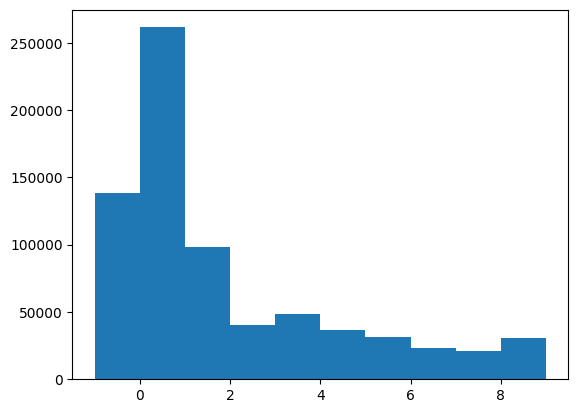

In [2]:
import matplotlib.pyplot as plt

x = df["elapsed_days"]
y = df["duration"] / 1000

plt.hist(x[x < 10])

array([-0.07201925, 13.84395615])

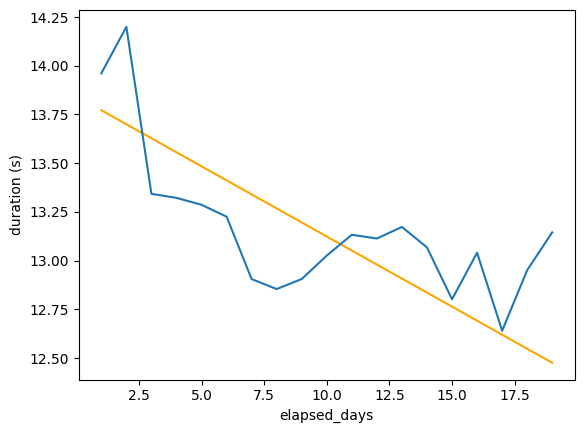

In [20]:
end = 20

filtered_df = df[(df["elapsed_days"] > 0) & (df["elapsed_days"] < end)]

x = filtered_df["elapsed_days"]
y = filtered_df["duration"] / 1000

c = np.polyfit(x, y, 1)
plt.plot(np.arange(1, end), np.polyval(c, np.arange(1, end)), color="orange")
plt.plot(np.arange(1, end), filtered_df.groupby("elapsed_days")["duration"].mean() / 1000)

plt.xlabel("elapsed_days")
plt.ylabel("duration (s)")
c